<a href="https://colab.research.google.com/github/suhyeon523/Project3_ECON148/blob/main/notebooks/Project3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

#1. Data Loading, Filtering, and Reshaping of the Target Variable

##(1) Loading
Import the Zillow House Value Index (ZHVI) CSV file stored in GitHub into the Pandas data frame. This is a process to secure housing price time series data, which is a target variable of this project, and use it as data for analysis.

In [19]:
url = "https://raw.githubusercontent.com/suhyeon523/Project3_ECON148/refs/heads/main/data/Metro_ZHVI.csv"
zillow_data = pd.read_csv(url)
zillow_data.head()

,RegionID,SizeRank,RegionName,RegionType,StateName,2000-01-31,2000-02-29,2000-03-31,2000-04-30,2000-05-31,...,2025-06-30,2025-07-31,2025-08-31,2025-09-30,2025-10-31,2025-11-30,2025-12-31,2026-01-31,2026-02-28,2026-03-31
0,102001,0,United States,country,NaN,122723.314722,122939.224374,123206.984135,123781.276262,124442.217647,...,362560.842583,362132.841288,361904.476773,362146.820735,362582.459574,363260.484023,364053.711171,364810.501924,365526.782311,366018.815220
1,394913,1,"New York, NY",msa,NY,217784.554624,218710.016103,219644.049023,221536.761145,223496.730091,...,692740.899026,693911.257366,694699.788803,696097.775239,698428.981973,701765.079321,705178.795698,708236.709315,711803.048283,715583.951353
2,753899,2,"Los Angeles, CA",msa,CA,224762.443660,225598.845127,226712.923903,228929.566423,231353.878418,...,957170.045940,954540.625630,953453.887828,954525.850586,956976.849684,960342.016204,964358.917595,966925.310466,968174.896554,967836.201342
3,394463,3,"Chicago, IL",msa,IL,153387.535332,153529.527506,153799.954104,154472.708272,155281.950617,...,332166.351158,333005.360528,334000.754039,335333.297892,336637.606600,338184.663240,339916.392330,341535.828444,343281.802377,344686.992147
4,394514,4,"Dallas, TX",msa,TX,129543.865799,129601.565090,129667.896331,129840.151596,130067.265447,...,371756.987502,369710.155065,368327.677314,367670.920611,367317.108777,367049.499400,366828.525223,366388.507924,365804.694106,364734.092138


##(2) Filtering
The three metros we selected are San Francisco, Austin, and Cleveland, and only the data from these three cities are extracted and used for analysis.

In [20]:
target_metros = ["San Francisco, CA","Austin, TX","Cleveland, OH"]
filtered_zillow_data = zillow_data[zillow_data["RegionName"].isin(target_metros)].copy()
filtered_zillow_data.head()

,RegionID,SizeRank,RegionName,RegionType,StateName,2000-01-31,2000-02-29,2000-03-31,2000-04-30,2000-05-31,...,2025-06-30,2025-07-31,2025-08-31,2025-09-30,2025-10-31,2025-11-30,2025-12-31,2026-01-31,2026-02-28,2026-03-31
12,395057,12,"San Francisco, CA",msa,CA,294910.648524,296064.279497,297822.516408,302592.381757,309166.105394,...,1.144028e+06,1.135551e+06,1.128818e+06,1.126615e+06,1.127651e+06,1.131534e+06,1.136832e+06,1.139902e+06,1.142086e+06,1.143246e+06
29,394355,29,"Austin, TX",msa,TX,176345.254321,176925.128914,177456.082518,178300.266555,178937.765779,...,4.440598e+05,4.406251e+05,4.382744e+05,4.369826e+05,4.360398e+05,4.348754e+05,4.334607e+05,4.317391e+05,4.297141e+05,4.270448e+05
34,394475,35,"Cleveland, OH",msa,OH,117213.339774,117385.213606,117560.834251,117927.272621,118492.389122,...,2.361570e+05,2.372409e+05,2.381333e+05,2.391256e+05,2.398276e+05,2.407482e+05,2.417448e+05,2.427292e+05,2.436641e+05,2.444691e+05


##(3) Reshaping
The current data has all the dates listed in columns. We convert the date columns into rows to facilitate time series analysis. First, combine the date columns into one except for the columns to be fixed. Then convert the dates into a format that Python can recognize, and cleanly organize the mixed and cluttered order of metros and dates.

In [103]:
filtered_data = filtered_zillow_data.drop(columns=['RegionID','RegionType','StateName','SizeRank']).copy()
fixed_columns = ['RegionName']
reshaped_data = pd.melt(filtered_data, id_vars=fixed_columns, var_name='Date', value_name='ZHVI')
reshaped_data['Date'] = pd.to_datetime(reshaped_data['Date'])
reshaped_data = reshaped_data.sort_values(by=['RegionName', 'Date']).reset_index(drop=True)
reshaped_data.head()

,RegionName,Date,ZHVI
0,"Austin, TX",2000-01-31,176345.254321
1,"Austin, TX",2000-02-29,176925.128914
2,"Austin, TX",2000-03-31,177456.082518
3,"Austin, TX",2000-04-30,178300.266555
4,"Austin, TX",2000-05-31,178937.765779


##(4) Exploratory Data Analysis - Time Series Plot
Now, visualize the housing prices of the three metros so that we can see how they change over time. Plot a line graph for each of the three metros.

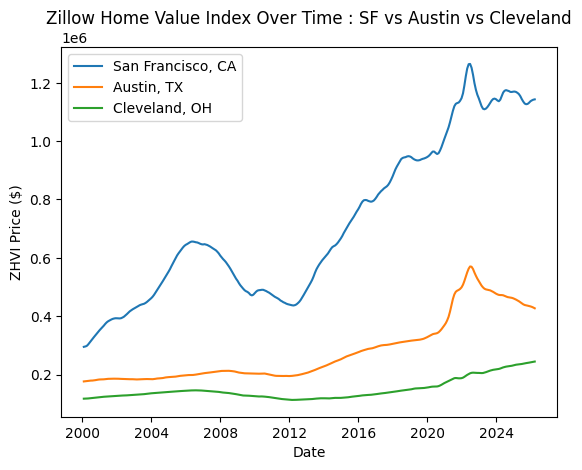

In [105]:
for metro in target_metros:
    metro_data = reshaped_data[reshaped_data['RegionName'] == metro]
    plt.plot(metro_data['Date'], metro_data['ZHVI'], label = metro)
plt.title('Zillow Home Value Index Over Time : SF vs Austin vs Cleveland')
plt.xlabel('Date')
plt.ylabel('ZHVI Price ($)')
plt.legend()
plt.show()

#2. Collection of external variables
Having defined the target variable, housing prices, we proceed to collect explanatory variables (FRED macro series, Census ACS demographics, and mortgage rate data) that affect housing prices for the construction of a nowcasting model.

##(1) FRED macro series
We first utilize the Federal Reserve Economic Data (FRED) API to collect key macroeconomic indicators. The selected FRED macro series include the unemployment rate (labor market condition), the Consumer Price Index (inflation), and personal income as a proxy for housing affordability. Since nowcasting is conducted at a monthly frequency, we standardize all data to a monthly frequency during data collection. We begin by installing the FRED API package.

In [106]:
!pip install fredapi
from fredapi import Fred

<1> Next, we collect data from FRED API and enforce a monthly frequency for all series.

In [107]:
def fetch_fred_series(api_key, series_id):
    fred = Fred(api_key=api_key)
    series = fred.get_series(series_id, frequency='m')
    return series

<2> The three macroeconomic time series are merged into a unified dataset, and rows containing missing values are dropped to ensure that only complete observations are retained.

In [108]:
def compile_macro_data(api_key):
    unrate = fetch_fred_series(api_key, 'UNRATE')
    cpi = fetch_fred_series(api_key, 'CPIAUCSL')
    income = fetch_fred_series(api_key, 'PI')
    macro_df = pd.DataFrame({'Unrate': unrate, 'CPI': cpi, 'Income': income})
    macro_df.index.name = 'Date'
    return macro_df.dropna().reset_index()
my_key = '5c08d8bf72bf6adc502870943972777e'
macro_df = compile_macro_data(my_key)

<3> We standardize the date format in order to merge this dataset with the Zillow data.

In [109]:
macro_df['Date'] = pd.to_datetime(macro_df['Date'])
print(macro_df.head())

        Date  Unrate    CPI  Income
0 1959-01-01     6.0  29.01   391.8
1 1959-02-01     5.9  29.00   393.7
2 1959-03-01     5.6  28.97   396.5
3 1959-04-01     5.2  28.98   399.9
4 1959-05-01     5.1  29.04   402.4


##(2) mortgage rate
When mortgage rates rise, borrowing costs increase, which reduces housing demand and ultimately puts downward pressure on house prices. Therefore, we now collect mortgage rates, a key determinant of housing purchase costs. In this case as well, we collect data at a monthly frequency.

In [110]:
def fetch_mortgage_data(api_key):
    fred = Fred(api_key=api_key)
    mortgage = fred.get_series('MORTGAGE30US', frequency='m')
    mortgage_df = pd.DataFrame({'Mortgage_Rate': mortgage})
    mortgage_df.index.name = 'Date'
    return mortgage_df.dropna().reset_index()
mortgage_df = fetch_mortgage_data(my_key)
mortgage_df['Date'] = pd.to_datetime(mortgage_df['Date'])
print(mortgage_df.head())

        Date  Mortgage_Rate
0 1971-04-01           7.31
1 1971-05-01           7.43
2 1971-06-01           7.53
3 1971-07-01           7.60
4 1971-08-01           7.70


Before collecting additional demographic data, we merge the existing macro_df, mortgage_df, and reshaped Zillow dataset into a single dataset. The merge is performed based on the ‘Date’ column, ensuring that all columns from each dataset are fully retained. Meanwhile, when merging by date, we align the date formats of the FRED and Zillow datasets by setting all dates to the first day of each month.

In [111]:
reshaped_data['Date'] = pd.to_datetime(reshaped_data['Date']).dt.to_period('M').dt.to_timestamp().copy()
fred_data = pd.merge(macro_df, mortgage_df, on='Date', how='inner')
merged_df = pd.merge(reshaped_data, fred_data, on='Date', how='inner')
merged_df.head()

,RegionName,Date,ZHVI,Unrate,CPI,Income,Mortgage_Rate
0,"Austin, TX",2000-01-01,176345.254321,4.0,169.3,8348.0,8.21
1,"Austin, TX",2000-02-01,176925.128914,4.1,170.0,8408.8,8.33
2,"Austin, TX",2000-03-01,177456.082518,4.0,171.0,8468.3,8.24
3,"Austin, TX",2000-04-01,178300.266555,3.8,170.9,8506.8,8.15
4,"Austin, TX",2000-05-01,178937.765779,4.0,171.2,8544.5,8.52


##(3) Census ACS demographics
While the previously collected FRED macroeconomic data captures overall national housing market conditions, we now collect American Community Survey (ACS) demographic data to better represent local housing demand and purchasing power. This step is intended to incorporate regional differences in market dynamics into the model. Using the ACS from the U.S. Census Bureau, we collect median household income, educational attainment (share of individuals with a bachelor’s degree or higher), and total population for each metropolitan area. We use Census data extracted from FRED API, and convert these annual indicators into monthly series by assigning the same value to all months within each year to construct a complete monthly time series dataset. We begin by specifying the FRED series IDs used for each region.(We use Cuyahoga County data as a proxy for the Cleveland metropolitan area.)

In [112]:
fred = Fred(api_key='5c08d8bf72bf6adc502870943972777e')
census_ID = {
    "San Francisco, CA": {"Income":"MHICA06075A052NCEN","Education":"GCT1502CA","Population": "CAPOP"},
    "Austin, TX": {"Income":"MHITX48015A052NCEN","Education":"GCT1502TX","Population":"TXPOP"},
    "Cleveland, OH": {"Income":"MHIOH39035A052NCEN","Education":"GCT1502OH","Population":"OHPOP"}
}

Next, we initialize an empty list to store multiple Census data frames.

In [113]:
all_census = []

We collect data for each region defined in the dictionary. The data are retrieved via the FRED API and then converted into data frames with appropriately assigned column names. We then aggregate and merge the data by year, and append the resulting metro-level dataset to the previously initialized empty list.

In [114]:
for metro, IDs in census_ID.items():
    medinc = fred.get_series(IDs["Income"]).to_frame(name='MedianIncome')
    edu = fred.get_series(IDs["Education"]).to_frame(name='EduAttainment')
    pop = fred.get_series(IDs["Population"]).to_frame(name='TotalPopulation')
    metro_census = pd.concat([medinc, edu, pop], axis=1).reset_index()
    metro_census.rename(columns={'index':'Year'}, inplace=True)
    metro_census['Year'] = metro_census['Year'].dt.year
    metro_census = metro_census.groupby('Year').mean().reset_index()
    metro_census['RegionName'] = metro
    all_census.append(metro_census)

We combine the datasets for the three metros stored in the list into a single dataset.

In [115]:
census_data = pd.concat(all_census)
census_data.head()

,Year,MedianIncome,EduAttainment,TotalPopulation,RegionName
0,1900,NaN,NaN,1490.0,"San Francisco, CA"
1,1901,NaN,NaN,1550.0,"San Francisco, CA"
2,1902,NaN,NaN,1623.0,"San Francisco, CA"
3,1903,NaN,NaN,1702.0,"San Francisco, CA"
4,1904,NaN,NaN,1792.0,"San Francisco, CA"


##(4) Construction of the Unified Analytical Dataset
Merge the target variable, Zillow ZHVI data, and external explanatory variables—FRED macroeconomic indicators, mortgage rates, and Census ACS demographic data—into a single dataframe based on 'Date' and 'RegionName'. This is to secure a unified dataset for analysis by aligning all independent and dependent variables at the same unit of observation (Month-Metro) for time-series analysis and machine learning model training. Since the merged_data is at a monthly frequency, we first extract the year to ensure consistency in the merging criteria.

In [116]:
merged_df['Year'] = merged_df['Date'].dt.year
final_data = pd.merge(merged_df, census_data, on=['RegionName','Year'], how='left')

Since Census data are available only at an annual frequency and are released with a time lag, we impute missing values by assuming that demographic characteristics remain stable in the short term. This approach preserves the continuity of the time series. Any remaining missing values are strictly dropped to ensure data integrity.

In [120]:
for col in ['MedianIncome','EduAttainment','TotalPopulation']:
    final_data[col] = final_data.groupby('RegionName')[col].ffill()
final_dataset = final_data.dropna().reset_index(drop=True)
final_dataset = final_dataset.drop(columns='Year')
final_dataset.head()

,RegionName,Date,ZHVI,Unrate,CPI,Income,Mortgage_Rate,MedianIncome,EduAttainment,TotalPopulation
0,"Austin, TX",2006-01-01,197823.426792,4.7,199.3,11038.6,6.15,46603.0,24.7,23359.58
1,"Austin, TX",2006-02-01,198140.956992,4.8,199.4,11102.6,6.25,46603.0,24.7,23359.58
2,"Austin, TX",2006-03-01,198154.990018,4.7,199.7,11171.8,6.32,46603.0,24.7,23359.58
3,"Austin, TX",2006-04-01,198242.907561,4.7,200.7,11229.5,6.51,46603.0,24.7,23359.58
4,"Austin, TX",2006-05-01,198447.835467,4.6,201.3,11251.1,6.60,46603.0,24.7,23359.58
